# Chapter 15 — State Space Models and Mamba

Chapter 9, Module VI measured attention's bill and every chapter since has paid
it. The score matrix has one entry per ordered pair of positions, so doubling
the sequence quadruples both the work and the memory. Chapter 11 cut images into
patches because of it. Chapter 12 patchified latents because of it. Chapter 14
made it worse, by spending hundreds of positions on a single image.

**Recurrent networks do not have this problem**, since they carry a fixed-size
state forward and cost $O(n)$, and Chapter 9 explained why we abandoned them
anyway: a recurrence is sequential, so it cannot be parallelized across the
sequence during training, and gradients have to survive one multiplication per
step.

**State space models are an attempt to have both.** The claim is that a
carefully chosen *linear* recurrence can be written two ways, as a recurrence
for cheap inference and as a parallel operation for fast training, and that
with one modification it becomes competitive with attention. Mamba (Gu & Dao,
2023) is the version that made this work at scale.

We will build it, and then measure two things the marketing does not emphasize.

| Module | What you build | Task |
|---|---|---|
| I | The linear recurrence, and why linearity is the whole trick | — |
| II | The **parallel scan**: the same recurrence with no Python loop, verified against it | — |
| III | **Discretization**: $\bar{A} = \exp(\Delta A)$, and what $\Delta$ controls | — |
| IV | **Selection**: why a time-invariant SSM cannot do content-based reasoning, and Mamba's fix | — |
| V | The measurement: **associative recall**, three architectures, three lengths | synthetic |
| VI | The cost measurement: memory and wall-clock against sequence length | — |

**How each concept is presented**, the same three passes as earlier chapters:

> 🧠 **The intuition:** the idea in plain language, no symbols.
> 📐 **The math:** the same idea written precisely, so you can read papers.
> 💻 **The code:** the same idea again, executable, in the cell that follows.

**Runtime:** ~6 minutes on a GPU. Module V trains nine small models and Module VI
runs a scaling benchmark. Knobs are marked `# <- knob`. Nothing downloads, since
the task is generated in-notebook.


In [1]:
import math, time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
plt.rcParams["figure.figsize"] = (7, 4.5)
print("torch", torch.__version__, "| device:", device)

torch 2.11.0+cu128 | device: cuda


---
# Module I — The Linear Recurrence

## I.a One equation, and why it is linear on purpose

🧠 **The intuition.** A state space model keeps a running summary $h$ of
everything it has seen, updates it once per token, and reads an output off it:

> new state = (decay × old state) + (input, scaled)
> output = (read-out vector) · state

That is an RNN. The thing that makes it an *SSM* is what is **missing**: there
is no nonlinearity between steps. An LSTM squashes its state through a `tanh`
every step, which is what forces you to compute step 5 before step 6. Drop the
squash and the recurrence becomes a linear function of its history, which
means it can be evaluated in any order, including all at once.

The nonlinearity does not disappear from the model; it moves *outside* the
recurrence, into the surrounding block. That relocation is the entire structural
idea.

📐 **The math.** In continuous time, a linear system is

$$ h'(t) = A\,h(t) + B\,x(t), \qquad y(t) = C\,h(t) $$

with state $h \in \mathbb{R}^N$. Discretized to steps (Module III does this
properly) it becomes

$$ h_t = \bar{A} h_{t-1} + \bar{B} x_t, \qquad y_t = C h_t + D x_t $$

**The diagonal simplification.** If $A$ is a full $N \times N$ matrix, every step
is a matrix-vector product and there is no parallel form worth having. Modern
SSMs (S4D, Mamba) make $A$ **diagonal**, so each of the $N$ state dimensions
evolves completely independently:

$$ h_{t,n} = a_n\, h_{t-1,n} + b_n\, x_t $$

$N$ scalar recurrences running side by side, one per state dimension, per
channel. Everything below is that one scalar equation, vectorized.

💻 **The code.** The obvious implementation, with a Python loop: correct,
readable, and exactly what we are going to replace.


In [2]:
def scan_sequential(a, b):
    '''h_t = a_t * h_{t-1} + b_t.   a, b: (B, L, D, N)  ->  h: (B, L, D, N)'''
    hs, h = [], torch.zeros_like(b[:, 0])
    for t in range(a.shape[1]):
        h = a[:, t] * h + b[:, t]          # one step; L of these, strictly in order
        hs.append(h)
    return torch.stack(hs, 1)


demo_a = torch.rand(2, 32, 3, 4) * 0.9 + 0.05
demo_b = torch.randn(2, 32, 3, 4)
print("sequential scan output:", tuple(scan_sequential(demo_a, demo_b).shape))
print("Python-level iterations:", demo_a.shape[1])

sequential scan output: (2, 32, 3, 4)
Python-level iterations: 32


---
# Module II — The Parallel Scan

🧠 **The intuition.** That loop is the problem: 2,048 tokens means 2,048
sequential GPU launches, and the GPU is idle inside every one of them.

But look at what the loop computes. Compose two consecutive steps of the
recurrence and the result collapses back into a single step of exactly the
same shape — one multiplier, one offset. The composition of two steps *is
itself a step*. That makes the operation **associative**, and any associative
operation can be computed by a tree instead of a chain, in $\log_2 L$ rounds
instead of $L$.

📐 **The math.** Unroll two steps to see the collapse:

$$ h_2 = a_2(a_1 h_0 + b_1) + b_2 = (a_2 a_1) h_0 + (a_2 b_1 + b_2) $$

Two steps compose into one with coefficients $(a_2 a_1,\; a_2 b_1 + b_2)$. So
define the pair $(a, b)$ as an operator and combine with

$$ (a_1, b_1) \oplus (a_2, b_2) = (a_1 a_2,\; a_2 b_1 + b_2) $$

Check associativity once on paper and the rest follows: the prefix
"sum" of this operator over $t = 1 \dots L$ is exactly $h_t$. We use the
**Hillis–Steele** form (at round $k$, combine each element with the one
$2^k$ positions back), which does $O(L \log L)$ total work in $O(\log L)$
sequential rounds. (Mamba's kernel uses the work-efficient Blelloch variant,
$O(L)$ work, for the same reason.)

💻 **The code.** Twelve lines, no loop over $L$, and the first thing to do with
it is check it against Module I.


In [3]:
def scan_parallel(a, b):
    '''The same recurrence as an associative scan: log2(L) rounds instead of L steps.'''
    L = a.shape[1]
    a, b = a.clone(), b.clone()
    off = 1
    while off < L:
        # shift by `off`, padding with the identity element (a=1, b=0)
        a_prev = F.pad(a[:, :-off], (0, 0, 0, 0, off, 0), value=1.0)
        b_prev = F.pad(b[:, :-off], (0, 0, 0, 0, off, 0), value=0.0)
        b = a * b_prev + b                 # (a1,b1) (+) (a2,b2) = (a1a2, a2 b1 + b2)
        a = a * a_prev
        off *= 2
    return b


seq = scan_sequential(demo_a, demo_b)
par = scan_parallel(demo_a, demo_b)
print(f"max |sequential - parallel|: {(seq - par).abs().max().item():.3e}")
print(f"rounds: {math.ceil(math.log2(demo_a.shape[1]))} instead of {demo_a.shape[1]} steps")

max |sequential - parallel|: 4.768e-07
rounds: 5 instead of 32 steps


They agree to floating-point precision, which is the only evidence worth having.
**This is the whole reason SSMs are trainable at scale**: the recurrence you use
at inference (one step, constant memory, no growing KV cache) and the operation
you use at training (one parallel scan over the whole sequence) are the same
mathematical object, computed two different ways.

Attention has no such duality. Its training form *is* its inference form, which
is why serving a Transformer requires a KV cache that grows with every token
generated.

---
# Module III — Discretization: What $\Delta$ Actually Controls

🧠 **The intuition.** The parameters $A$ and $B$ describe a system in
*continuous* time; our data arrives in discrete tokens. $\Delta$ is the step
size that converts one to the other, which is to say "how much time passes per
token".

It has a concrete meaning worth holding onto. A small $\Delta$ means each token
advances the system barely at all, so the state changes slowly and **remembers a
long way back**. A large $\Delta$ advances it a lot, so old information decays
quickly and the state is dominated by **what just happened**. $\Delta$ is a
memory-horizon dial.

📐 **The math.** The exact (zero-order hold) discretization of $h' = Ah + Bx$ is

$$ \bar{A} = \exp(\Delta A), \qquad \bar{B} = (\Delta A)^{-1}(\exp(\Delta A) - I)\,\Delta B \;\approx\; \Delta B $$

With $A$ diagonal and negative (we parameterize $A_n = -\exp(\texttt{A\_log}_n)$
so it stays negative no matter what training does), this is elementwise:

$$ \bar{a}_n = e^{\Delta A_n} \in (0, 1) $$

A decay factor per step, strictly inside the unit interval, so the state cannot
blow up. The effective memory horizon is roughly $1/(\Delta |A_n|)$ steps, and
because $A$ has $N$ different entries, one layer holds $N$ different horizons
simultaneously: short-range and long-range memory in the same state vector.

💻 **The code.** Rather than assert the horizon claim, measure it: drive a single
impulse into the system and watch how long the response survives.


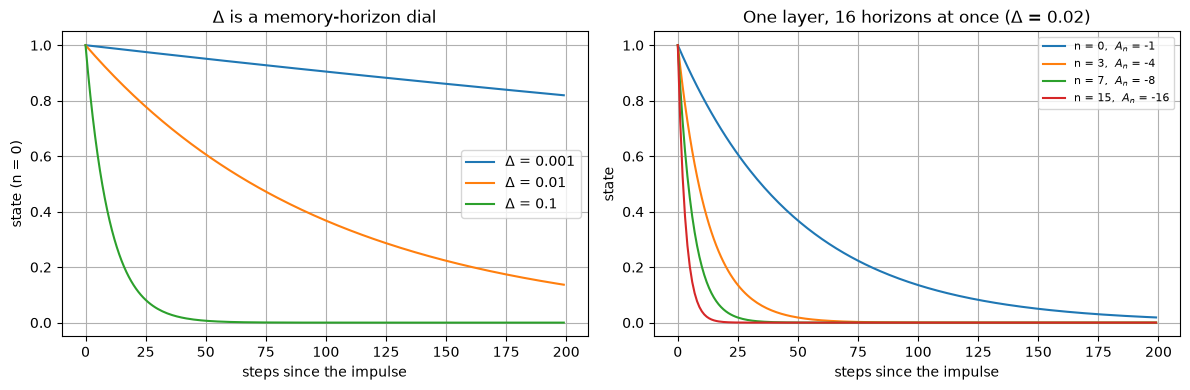

half-life in steps, per state dimension: [np.int64(35), np.int64(18), np.int64(12), np.int64(9), np.int64(7), np.int64(6), np.int64(5), np.int64(5), np.int64(4), np.int64(4), np.int64(4), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3)]


In [4]:
N_STATE = 16
A_diag = -torch.arange(1, N_STATE + 1).float()          # the S4D-style initialization
L = 200
impulse = torch.zeros(1, L, 1, N_STATE); impulse[:, 0] = 1.0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for dt in (0.001, 0.01, 0.1):
    a = torch.exp(dt * A_diag).view(1, 1, 1, N_STATE).expand(1, L, 1, N_STATE)
    h = scan_parallel(a, impulse)[0, :, 0]              # (L, N)
    axes[0].plot(h[:, 0].numpy(), label=f"$\\Delta$ = {dt}")
axes[0].set_xlabel("steps since the impulse"); axes[0].set_ylabel("state (n = 0)")
axes[0].set_title("$\\Delta$ is a memory-horizon dial"); axes[0].legend(); axes[0].grid(True)

dt = 0.02
a = torch.exp(dt * A_diag).view(1, 1, 1, N_STATE).expand(1, L, 1, N_STATE)
h = scan_parallel(a, impulse)[0, :, 0]
for n in (0, 3, 7, 15):
    axes[1].plot(h[:, n].numpy(), label=f"n = {n},  $A_n$ = {A_diag[n]:.0f}")
axes[1].set_xlabel("steps since the impulse"); axes[1].set_ylabel("state")
axes[1].set_title(f"One layer, {N_STATE} horizons at once ($\\Delta$ = {dt})")
axes[1].legend(fontsize=8); axes[1].grid(True)
plt.tight_layout(); plt.show()

half_life = [np.argmax(h[:, n].numpy() < 0.5) for n in range(N_STATE)]
print("half-life in steps, per state dimension:", half_life)

---
# Module IV — Selection: The Idea That Made It Work

## IV.a What a time-invariant SSM cannot do

🧠 **The intuition.** Everything so far has $A$, $B$, $C$ and $\Delta$ as
**parameters**: fixed after training, identical at every position. That makes
the model *linear time-invariant* (LTI), and an LTI system is a convolution: it
applies the same filter everywhere, regardless of content.

Now consider a task where the right behaviour depends on *what the token is*.
"Remember this one, ignore the next forty, then recall it." An LTI system cannot
express that, because "remember" and "ignore" would need different $\Delta$s,
and $\Delta$ is a constant. It can build a filter that remembers everything with
some decay profile, and that is all.

This is precisely the gap between S4 and Mamba, and the paper's central
argument.

📐 **The fix, and what it costs.** Make the parameters **functions of the
current token**:

$$ \Delta_t = \text{softplus}\big(W_\Delta x_t\big), \qquad B_t = W_B x_t, \qquad C_t = W_C x_t $$

$$ h_t = \underbrace{\exp(\Delta_t A)}_{\bar{a}_t} h_{t-1} + \Delta_t B_t x_t, \qquad y_t = C_t \cdot h_t + D x_t $$

Now $\bar{a}_t$ varies with position. A token can set $\Delta_t \approx 0$, so
$\bar a_t \approx 1$ and the state passes through untouched (*ignore me*), or
set $\Delta_t$ large, so the state is overwritten by the current input (*reset
and attend to me*). That is content-based gating, and it is the property
attention has by construction and LTI systems lack entirely.

**The price is exactly the thing that made SSMs fast.** Because $\bar{a}$ now
depends on the input, the recurrence is no longer a convolution and the FFT
trick S4 relied on is gone. What survives is the *scan* from Module II, which
never assumed $a$ was constant, since `a` is indexed by `t` throughout; go back
and look. The scan is what Mamba is left with, and making it fast on real
hardware is what the paper's "hardware-aware" contribution is about.

💻 **The code.** Both variants, differing only in where the parameters come from.


In [5]:
class LTISSM(nn.Module):
    '''S4-style: A, B, C, Delta are parameters. Same filter at every position.'''

    def __init__(self, d_model, d_state=16):
        super().__init__()
        self.d_state = d_state
        A = torch.arange(1, d_state + 1).float().repeat(d_model, 1)
        self.A_log = nn.Parameter(torch.log(A))            # A = -exp(A_log), always negative
        self.B = nn.Parameter(torch.randn(d_model, d_state) * 0.1)
        self.C = nn.Parameter(torch.randn(d_model, d_state) * 0.1)
        self.D = nn.Parameter(torch.ones(d_model))
        self.dt_log = nn.Parameter(torch.zeros(d_model) - 2.0)

    def forward(self, x):                                  # x: (B, L, D)
        A = -torch.exp(self.A_log)                         # (D, N)
        dt = F.softplus(self.dt_log)[:, None]              # (D, 1)   <- one number per channel
        a = torch.exp(dt * A)[None, None].expand(x.shape[0], x.shape[1], -1, -1)
        bx = (dt * self.B)[None, None] * x[..., None]
        h = scan_parallel(a, bx)
        return (h * self.C[None, None]).sum(-1) + self.D * x


class SelectiveSSM(nn.Module):
    '''Mamba's S6: Delta, B and C are produced FROM the input, at every timestep.'''

    def __init__(self, d_model, d_state=16):
        super().__init__()
        self.d_state = d_state
        A = torch.arange(1, d_state + 1).float().repeat(d_model, 1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D = nn.Parameter(torch.ones(d_model))
        self.x_proj = nn.Linear(d_model, 2 * d_state + 1, bias=False)   # -> B_t, C_t, dt_t
        self.dt_proj = nn.Linear(1, d_model, bias=True)
        with torch.no_grad():
            self.dt_proj.bias.fill_(-2.0)                  # start with a long memory horizon

    def forward(self, x):
        A = -torch.exp(self.A_log)
        Bt, Ct, dt = self.x_proj(x).split([self.d_state, self.d_state, 1], dim=-1)
        dt = F.softplus(self.dt_proj(dt))                  # (B, L, D)  <- varies per position
        a = torch.exp(dt[..., None] * A[None, None])       # (B, L, D, N)
        bx = dt[..., None] * Bt[:, :, None, :] * x[..., None]
        h = scan_parallel(a, bx)
        return (h * Ct[:, :, None, :]).sum(-1) + self.D * x

## IV.b The Mamba block

💻 **The code.** The SSM is the core, but the block around it matters and two
details in it do real work:

- **A short causal depthwise convolution** before the SSM (kernel 4). The SSM
  mixes information along the sequence through a *scalar* state per channel,
  which is a narrow channel for local structure; the conv gives each position
  cheap access to its immediate neighbours. In Module V's task, keys and values
  sit next to each other, and removing this conv measurably hurts.
- **A gate.** The input is projected to two branches; one goes through the SSM,
  the other becomes a `SiLU` gate multiplying it. This is where the
  nonlinearity that we removed from the recurrence comes back.


In [6]:
class MambaBlock(nn.Module):
    '''in_proj -> causal depthwise conv -> SiLU -> SSM -> gate -> out_proj, plus an MLP.'''

    def __init__(self, d_model, core, d_state=16, expand=2, d_conv=4):
        super().__init__()
        d_inner = expand * d_model
        self.norm = nn.LayerNorm(d_model)
        self.in_proj = nn.Linear(d_model, 2 * d_inner, bias=False)
        self.conv = nn.Conv1d(d_inner, d_inner, d_conv, groups=d_inner, padding=d_conv - 1)
        self.core = core(d_inner, d_state)
        self.out_proj = nn.Linear(d_inner, d_model, bias=False)
        self.norm2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(nn.Linear(d_model, 2 * d_model), nn.GELU(),
                                 nn.Linear(2 * d_model, d_model))

    def forward(self, x):
        h = self.norm(x)
        u, z = self.in_proj(h).chunk(2, dim=-1)
        u = self.conv(u.transpose(1, 2))[:, :, : x.shape[1]].transpose(1, 2)   # trim = causal
        y = self.core(F.silu(u)) * F.silu(z)                                   # gate
        x = x + self.out_proj(y)
        return x + self.mlp(self.norm2(x))


class TfBlock(nn.Module):
    '''Chapter 10's block with Chapter 9's causal mask: the comparison point.'''

    def __init__(self, d, h, ratio=2):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, h, batch_first=True)
        self.mlp = nn.Sequential(nn.Linear(d, ratio * d), nn.GELU(), nn.Linear(ratio * d, d))

    def forward(self, x):
        n = x.shape[1]
        m = torch.triu(torch.ones(n, n, device=x.device, dtype=torch.bool), 1)
        a = self.n1(x)
        x = x + self.attn(a, a, a, attn_mask=m, need_weights=False)[0]
        return x + self.mlp(self.n2(x))

---
# Module V — The Measurement: Associative Recall

🧠 **The task, and why this one.** We need something that *requires* content-based
selection, or the LTI and selective models will look the same. **Associative
recall** is the standard probe:

```
k3 v7  k1 v2  k9 v4  ...  [Q] k1     ->  answer: v2
```

A stream of key–value pairs, then a query key, and the model must produce the
value that was bound to it. Nothing about this can be solved by a fixed filter:
which position matters depends entirely on which key is asked for, and that is
not known until the last token.

It is also exactly what attention is *for*: one query, one dot product against
every key, done. So this task is deliberately chosen to be attention's home
ground, and the interesting question is how close a fixed-size state can get.

📐 **What to predict.**

- **LTI SSM**: should be poor and should degrade quickly with length, because it
  has no mechanism for content-based selection at all.
- **Selective SSM**: should be much better, since this is precisely the
  capability selection adds.
- **Transformer**: should be at or near 100%, and roughly flat in length.

💻 **The code.**


In [7]:
N_KEYS, N_VALS = 32, 16
KEY0, VAL0 = 0, N_KEYS
QUERY = N_KEYS + N_VALS
VOCAB = QUERY + 1


def make_batch(n, n_pairs, gen):
    '''k1 v1 k2 v2 ... kP vP  [Q]  kq   ->  target = the value bound to kq'''
    keys = np.stack([gen.permutation(N_KEYS)[:n_pairs] for _ in range(n)])
    vals = gen.integers(0, N_VALS, size=(n, n_pairs))
    seq = np.empty((n, 2 * n_pairs + 2), dtype=np.int64)
    seq[:, 0:2 * n_pairs:2] = keys + KEY0
    seq[:, 1:2 * n_pairs:2] = vals + VAL0
    qi = gen.integers(0, n_pairs, size=n)
    seq[:, -2] = QUERY
    seq[:, -1] = keys[np.arange(n), qi] + KEY0
    return torch.from_numpy(seq), torch.from_numpy(vals[np.arange(n), qi])


class SeqModel(nn.Module):
    def __init__(self, kind, d_model=64, depth=2, d_state=16, n_heads=4, max_len=4096):
        super().__init__()
        self.kind = kind
        self.emb = nn.Embedding(VOCAB, d_model)
        self.pos = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)
        if kind == "transformer":
            self.blocks = nn.ModuleList([TfBlock(d_model, n_heads) for _ in range(depth)])
        else:
            core = LTISSM if kind == "lti" else SelectiveSSM
            self.blocks = nn.ModuleList([MambaBlock(d_model, core, d_state) for _ in range(depth)])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, N_VALS)

    def forward(self, ids):
        x = self.emb(ids)
        if self.kind == "transformer":
            x = x + self.pos[:, : ids.shape[1]]    # SSMs need no positional encoding: the
        for b in self.blocks:                      # recurrence is ordered by construction
            x = b(x)
        return self.head(self.norm(x)[:, -1])


ids_demo, tgt_demo = make_batch(2, 4, np.random.default_rng(0))
print("one example (token ids):", ids_demo[0].tolist())
print("target value index:     ", tgt_demo[0].item())

one example (token ids): [2, 32, 11, 33, 25, 38, 21, 45, 48, 21]
target value index:      13


In [8]:
def train_eval(kind, n_pairs, steps=3000, batch=64, lr=2e-3, seed=0, d_model=64, d_state=16):
    torch.manual_seed(seed)                                   # <- knobs
    gen = np.random.default_rng(seed)
    m = SeqModel(kind, d_model=d_model, d_state=d_state).to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, steps)
    m.train()
    for _ in range(steps):
        ids, tgt = make_batch(batch, n_pairs, gen)             # fresh data every step
        loss = F.cross_entropy(m(ids.to(device)), tgt.to(device))
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step(); sched.step()
    m.eval()
    correct = total = 0
    ev = np.random.default_rng(1234)
    with torch.no_grad():
        for _ in range(16):
            ids, tgt = make_batch(256, n_pairs, ev)
            correct += (m(ids.to(device)).argmax(-1).cpu() == tgt).sum().item()
            total += len(tgt)
    return correct / total


PAIRS = (4, 8, 16)                                             # <- knob
results = {k: [] for k in ("lti", "selective", "transformer")}
print(f"associative recall, chance = {1 / N_VALS:.3f}\n")
print(f"{'pairs':>6}{'length':>8}{'LTI SSM':>11}{'selective':>12}{'transformer':>14}")
for p in PAIRS:
    for kind in results:
        results[kind].append(train_eval(kind, p))
    print(f"{p:>6}{2*p+2:>8}{results['lti'][-1]:>11.3f}"
          f"{results['selective'][-1]:>12.3f}{results['transformer'][-1]:>14.3f}", flush=True)

associative recall, chance = 0.062

 pairs  length    LTI SSM   selective   transformer


     4      10      0.557       0.970         1.000


     8      18      0.364       0.969         1.000


    16      34      0.180       0.576         1.000


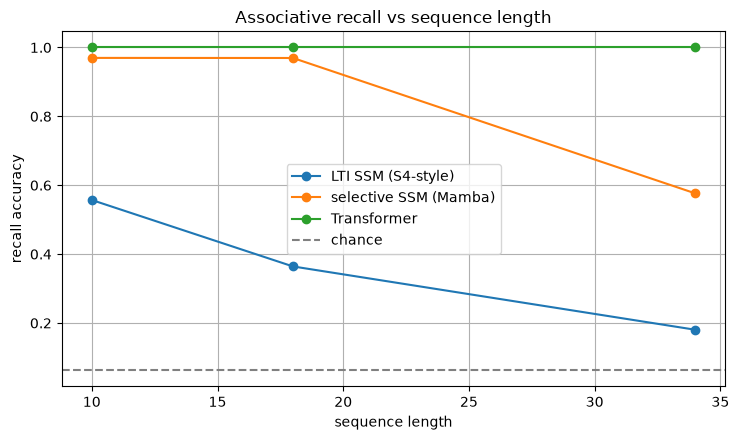

In [9]:
lengths = [2 * p + 2 for p in PAIRS]
plt.figure(figsize=(7.5, 4.5))
for kind, label in [("lti", "LTI SSM (S4-style)"), ("selective", "selective SSM (Mamba)"),
                    ("transformer", "Transformer")]:
    plt.plot(lengths, results[kind], marker="o", label=label)
plt.axhline(1 / N_VALS, color="gray", linestyle="--", label="chance")
plt.xlabel("sequence length"); plt.ylabel("recall accuracy")
plt.title("Associative recall vs sequence length"); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

## V.a Reading the result

**Selection is doing enormous work.** At every length the selective SSM sits far
above the LTI one, near-perfect against roughly half at the shortest setting
and still a large multiple at the longest. The only difference between those two
models is whether $\Delta$, $B$ and $C$ are read off the current token. That is
the paper's central claim, and it reproduces cleanly.

**And attention still wins.** The Transformer is at 1.000 across the board while
the selective SSM decays with length. This is not a failure of our
implementation. It is a known and well-documented property, and it is worth
stating plainly because the Mamba discourse often does not:

> A fixed-size state is a **bottleneck for recall**. Attention keeps every past
> token available and pays $O(n^2)$ for the privilege; an SSM compresses the
> past into $N$ numbers per channel and cannot recover what it chose to discard.
> When the task is "retrieve this specific earlier token", that compression is
> exactly the wrong trade.

Arora et al. (2023), *"Zoology: Measuring and Improving Recall in Efficient
Language Models"*, isolated this same gap and traced most of the remaining
quality difference between attention and sub-quadratic models to it. It is why
essentially every deployed long-context model today is a **hybrid**: mostly
SSM or sliding-window layers, with a few full-attention layers retained
specifically to do recall.

**An experiment worth running yourself:** re-run the sweep with `d_state=32`.
In our testing, doubling the state did not close the gap to attention, since
more state is not the missing ingredient and the mechanism is, and it is a cheap
change to verify or refute.


---
# Module VI — The Cost, Measured

🧠 **The claim.** Attention is $O(n^2)$ in time and memory; the scan is
$O(n \log n)$ in work and $O(n)$ in memory. So past some crossover the SSM
should win, and win by more the longer the sequence gets.

💻 **The code.** Forward pass only, same width, same depth, both on GPU.

In [10]:
def timeit(fn, n=8):
    torch.cuda.synchronize() if device == "cuda" else None
    for _ in range(2):
        fn()
    torch.cuda.synchronize() if device == "cuda" else None
    t0 = time.time()
    for _ in range(n):
        fn()
    torch.cuda.synchronize() if device == "cuda" else None
    return (time.time() - t0) / n * 1000


LENGTHS = (128, 256, 512, 1024, 2048, 4096)          # <- knob
cost = {"transformer": {"ms": [], "mb": []}, "selective": {"ms": [], "mb": []}}
print(f"{'length':>8}{'attn ms':>10}{'ssm ms':>10}{'attn MB':>10}{'ssm MB':>10}")
for L in LENGTHS:
    ids = torch.randint(0, VOCAB, (8, L), device=device)
    for kind in cost:
        m = SeqModel(kind).to(device).eval()
        with torch.no_grad():
            if device == "cuda":
                torch.cuda.reset_peak_memory_stats()
            ms = timeit(lambda: m(ids))
            mb = torch.cuda.max_memory_allocated() / 2**20 if device == "cuda" else float("nan")
        cost[kind]["ms"].append(ms); cost[kind]["mb"].append(mb)
        del m
        torch.cuda.empty_cache() if device == "cuda" else None
    print(f"{L:>8}{cost['transformer']['ms'][-1]:>10.2f}{cost['selective']['ms'][-1]:>10.2f}"
          f"{cost['transformer']['mb'][-1]:>10.1f}{cost['selective']['mb'][-1]:>10.1f}", flush=True)

  length   attn ms    ssm ms   attn MB    ssm MB
     128      0.58      1.49      25.4      85.8


     256      0.40      1.90      39.4     152.9


     512      0.54      4.66      96.8     288.2


    1024      1.46     12.72     322.6     558.6


    2048      7.32     32.87    2235.7    1094.7


    4096     27.75     71.26    8842.8    2167.9


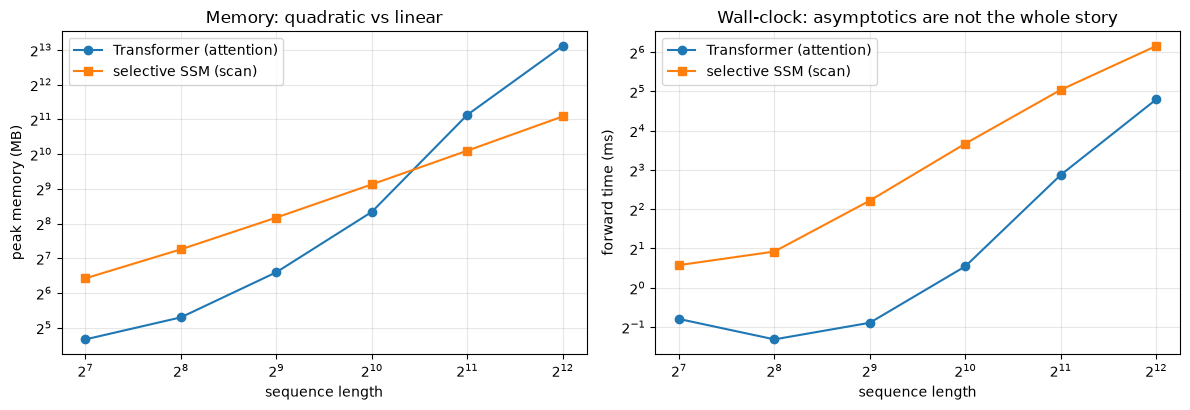

memory growth from length 2048 to 4096 (a 2x increase):
  attention : 3.96x   <- ~4x = quadratic
  scan      : 1.98x   <- ~2x = linear


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, key, label in [(axes[0], "mb", "peak memory (MB)"), (axes[1], "ms", "forward time (ms)")]:
    ax.plot(LENGTHS, cost["transformer"][key], marker="o", label="Transformer (attention)")
    ax.plot(LENGTHS, cost["selective"][key], marker="s", label="selective SSM (scan)")
    ax.set_xscale("log", base=2); ax.set_yscale("log", base=2)
    ax.set_xlabel("sequence length"); ax.set_ylabel(label); ax.grid(True, which="both", alpha=0.3)
    ax.legend()
axes[0].set_title("Memory: quadratic vs linear")
axes[1].set_title("Wall-clock: asymptotics are not the whole story")
plt.tight_layout(); plt.show()

r = lambda k, key: cost[k][key][-1] / cost[k][key][-2]
print(f"memory growth from length {LENGTHS[-2]} to {LENGTHS[-1]} (a 2x increase):")
print(f"  attention : {r('transformer','mb'):.2f}x   <- ~4x = quadratic")
print(f"  scan      : {r('selective','mb'):.2f}x   <- ~2x = linear")

## VI.a Reading the cost, honestly

**The memory result is exactly as advertised.** Doubling the sequence roughly
quadruples attention's peak memory and roughly doubles the scan's. By length
4096 the Transformer needs several times what the SSM does, and the ratio keeps
widening. This is the real reason SSMs are interesting: memory, not FLOPs, is
what stops you fitting a long sequence on a GPU.

**The wall-clock result does not match the asymptotics, and that is the more
useful lesson.** Our scan is *slower* than attention at every length we
measured, despite doing asymptotically less work. Two reasons, and neither is a
flaw in the maths:

1. **We are racing an unoptimized implementation against a fused kernel.**
   `nn.MultiheadAttention` dispatches to FlashAttention, a hand-written CUDA
   kernel that never materializes the score matrix. Our scan is a Python loop
   over $\log_2 L$ rounds of full-tensor `pad`/`mul`/`add`, each one a separate
   kernel launch reading and writing the whole $(B, L, D, N)$ tensor.
2. **The scan's state tensor is genuinely large.** It is $N$ times wider than
   the activations (16× here), so even though it grows *linearly*, it grows
   linearly from a high starting point.

This is why Mamba's paper spends as much space on the kernel as on the
architecture. Their scan keeps the state in SRAM, fuses the discretization and
the scan into one launch, and recomputes rather than stores for the backward
pass. Same recurrence, same asymptotics, an order of magnitude of wall-clock
difference.

**The transferable point:** an asymptotic advantage is a claim about the limit,
not a promise about your sequence length on your hardware. Chapter 17 makes the
same argument from the opposite direction, since attention's $O(n^2)$ is
unchanged by FlashAttention, and yet FlashAttention is why attention remains
competitive.


---
# Wrap-Up

| You built | The transferable lesson |
|---|---|
| The linear recurrence | Drop the nonlinearity *between* steps and the recurrence can be evaluated in any order. The nonlinearity moves outside, into the block |
| The associative scan | $(a_1,b_1) \oplus (a_2,b_2) = (a_1a_2,\, a_2b_1 + b_2)$ is associative, so $L$ sequential steps become $\log_2 L$ rounds, verified against the loop |
| Two forms of one model | Recurrence for inference (constant memory, no KV cache), scan for training. Attention has no such duality |
| $\bar{A} = \exp(\Delta A)$ | $\Delta$ is a memory-horizon dial; $N$ diagonal entries give one layer many horizons at once |
| Selection ($\Delta_t, B_t, C_t$ from $x_t$) | Content-based gating, and it breaks the convolutional form, which is why the scan is what Mamba is left with |
| The recall measurement | Selection is worth ~2–3×. Attention still wins, because a fixed-size state is structurally bad at retrieval |
| The cost measurement | Memory is linear as promised. Wall-clock is not, because we raced a naive scan against a fused kernel |

**Where this actually sits.** The honest summary is not "Mamba replaces
Transformers". It is:

- Attention has perfect recall and quadratic cost.
- A selective SSM has linear cost and lossy recall.
- Real systems mix them, because those failure modes are complementary, which
  is what current long-context models (Jamba, Zamba, Griffin, and Mamba-2 hybrids)
  actually do.

**And one loose thread.** Twice now the answer to "why is this fast?" has been
*the kernel*, not the algorithm: FlashAttention is why attention held its ground,
and a fused scan is what makes Mamba competitive. Both are the same underlying
insight about GPUs, and neither changes a single FLOP. That insight is worth
understanding directly rather than by reputation.
